# Laboratorio de Control Térmico: Diseño de PID


In [6]:
import tclab
import control as cs
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter

## Simulación para el sistema en oscilaciones perpetuas

Vamos a realizar como primer paso la simulación de nuestro sistema termico sin tiempo muerto, de modo que podamos observar un comportamiento base a nuestra planta realizada.

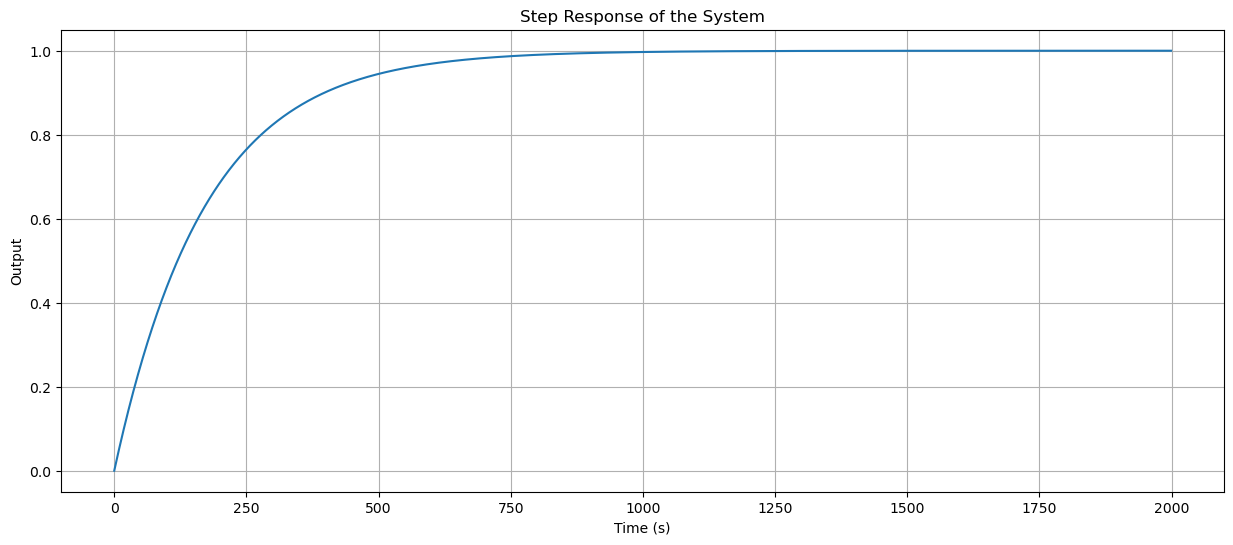

In [7]:
# Instance of our transfer function
k = 1
tau = 172.61
theta = 20.76

# Making no-dead time transfer function
G = cs.TransferFunction([k], [tau, 1])

# Time vector
t = range(0, 2000) # 0 to 2000 seconds

# Step response
t, y = cs.step_response(G, t)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(t, y)
plt.title('Step Response of the System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()


Para ahora nuevamente ver nuestra respuesta con respecto a una retroalimentación y variando nuestra ganancia K.

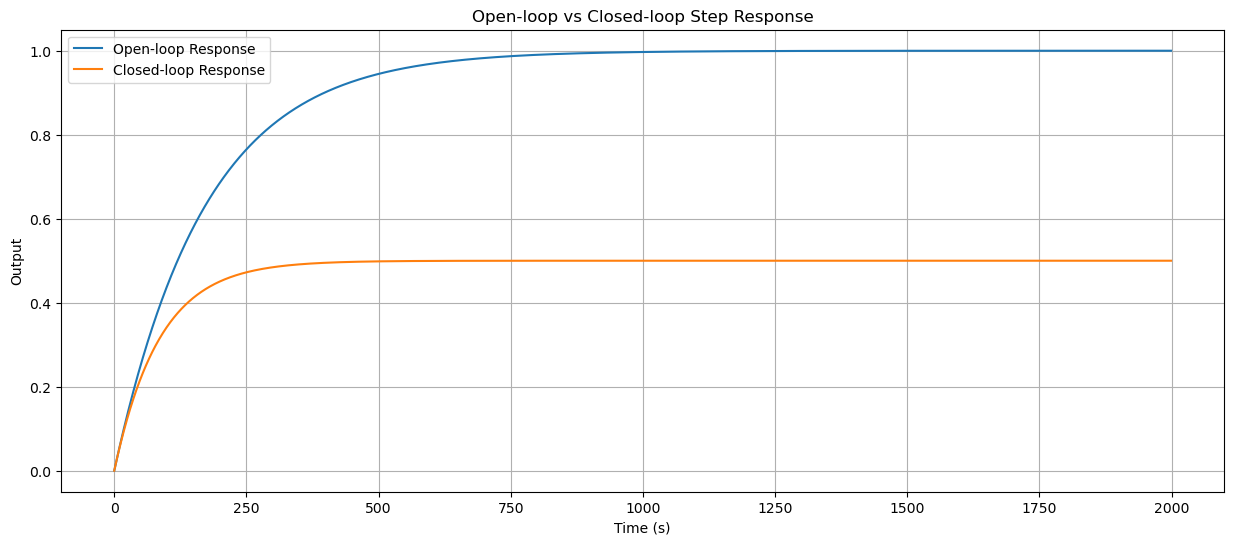

In [8]:
# Define new transfer function
Gs = cs.TransferFunction([k], [tau, 1])

# Define controller for Gs
Controller = cs.TransferFunction([1], [1])  # Proportional controller with gain 1

# Closed-loop transfer function
Closed_Loop = cs.feedback(Controller * Gs, 1)

# Step response of closed-loop system
t_cl, y_cl = cs.step_response(Closed_Loop, t)

# Plotting closed-loop response & open-loop response
plt.figure(figsize=(15, 6))
plt.plot(t, y, label='Open-loop Response')
plt.plot(t_cl, y_cl, label='Closed-loop Response')
plt.title('Open-loop vs Closed-loop Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.grid()

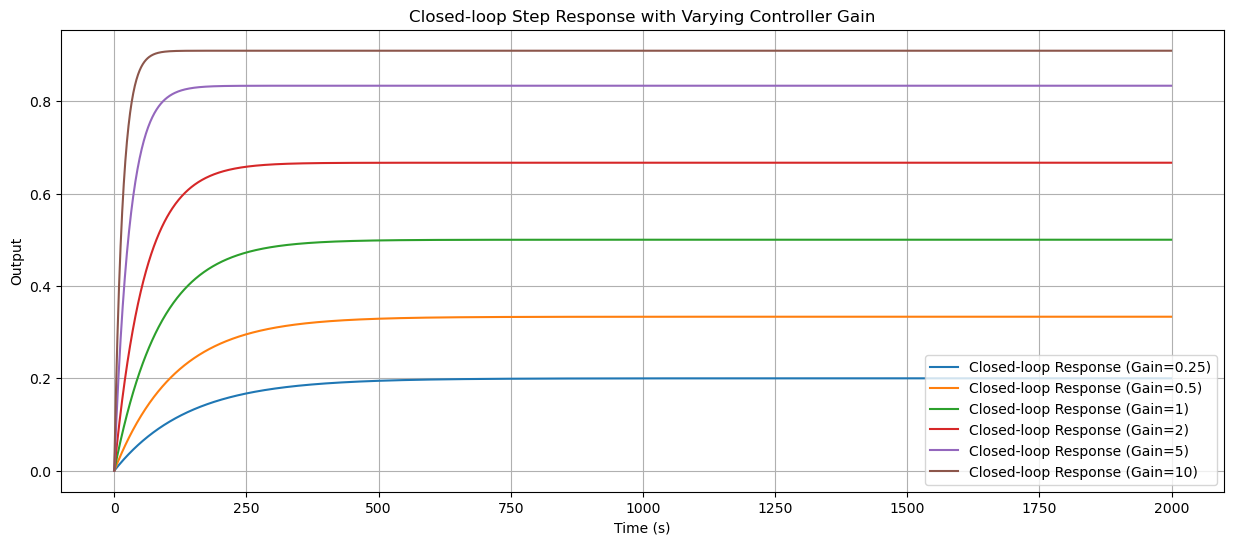

In [9]:
# New plot for the closed-loop response varying its controller value gain
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 10]:  # Different controller gains
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs, 1)  # Closed-loop transfer function
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Realizamos la simulación con tiempo muerto de lo previamente definido para observar oscilaciones en nuestro sistema.

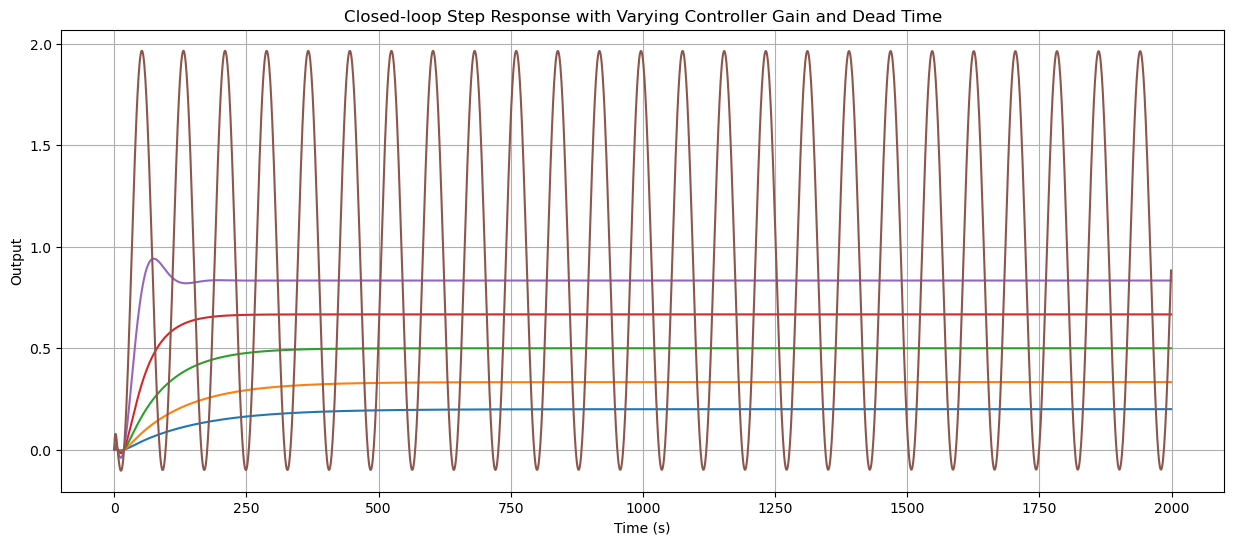

In [10]:
# Define new transfer function with dead time using Pade approximation
num, den = cs.pade(theta, 2)  # Pade approximation of dead time
Gs_dead_time = cs.TransferFunction(num, den) * Gs # System with dead time

# System configuration done with closed-loop control and proportional pure action
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 13.82]:  # Different controller gains - by varying the last value for the brown trace, we define 17.752 as a Ke
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs_dead_time, 1)  # Closed-loop transfer function

# Step response of closed-loop system
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response with Dead Time (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain and Dead Time')
plt.xlabel('Time (s)')
plt.ylabel('Output')
# Limit x-axis to better visualize the response
#plt.xlim(33,112)  
plt.grid()
plt.show()




Acorde a la variación de nuestro valores podemos decir que:

$$K_u \approx 13.82$$

$$P_u \approx 80s $$

## Comprobación real del sistema desde una ganancia acorde para las oscilaciones del sistema

Desde un valor

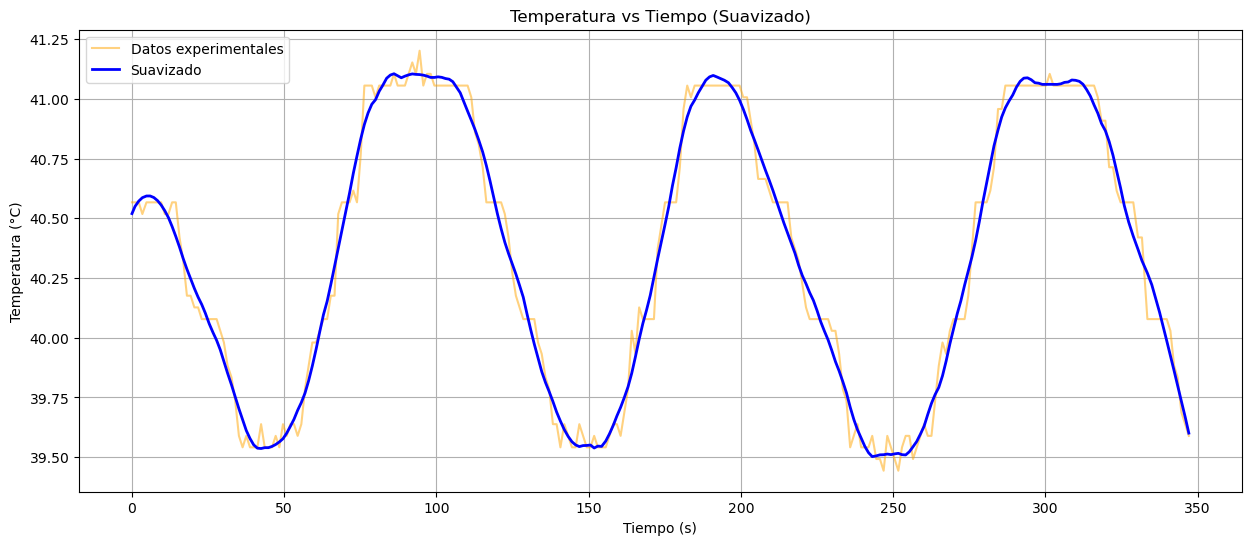

In [ ]:
# Open file
data = pd.read_csv('data_lab4/data_oscilacion.txt', encoding='latin1', sep=',')

# Extract data
time = data['Tiempo (s)']
temperature = data[' Temp1 (°C)']

# Softer curve using Savitzky-Golay filter
temperature_smooth = savgol_filter(temperature, window_length=21, polyorder=3)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, temperature, label='Datos experimentales', color='orange', alpha=0.5)
plt.plot(time, temperature_smooth, label='Suavizado', color='blue', linewidth=2)

plt.title('Temperatura vs Tiempo (Suavizado)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid()
plt.show()


# Diseño del Controlador 

## Simulación para el control PID

Con nuestros parametros previamente calculados de $K_u$ y $P_u$, definimos nuestros parametros para el PID con Ziegler Nichols.

$$K_p \approx 8.3$$

$$T_i \approx 40s$$

$$T_d \approx 10s$$

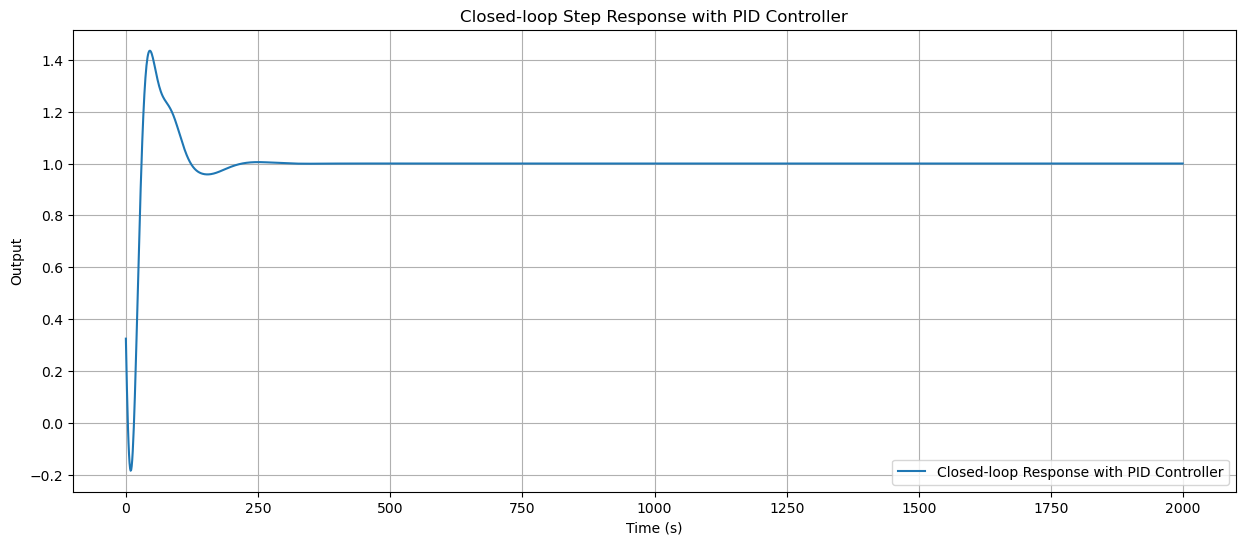

In [12]:
K_u = 13.82 # Gain from simulation for oscillations with pure proportional control
K_p = 0.6 * K_u # Gain for PID controller using Ziegler-Nichols tuning rules
T_i = 40
T_d = 10

# Calculate integral and derivative gains
K_i = K_p / T_i
K_d = K_p * T_d

# Design transfer function for PID controller
num = [K_d, K_p, K_i]  # PID controller numerator coefficients
den = [1, 0]  # PID controller denominator coefficients (s^2 term for derivative action)

PID_Controller = cs.TransferFunction(num, den)
Closed_Loop_PID = cs.feedback(PID_Controller * Gs_dead_time, 1)

# Step response of closed-loop system with PID controller
t_cl, y_cl = cs.step_response(Closed_Loop_PID, t)

# Plotting closed-loop response with PID controller
plt.figure(figsize=(15, 6))
plt.plot(t_cl, y_cl, label='Closed-loop Response with PID Controller')
plt.title('Closed-loop Step Response with PID Controller')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()




## Comprobación real del funcionamiento del PID

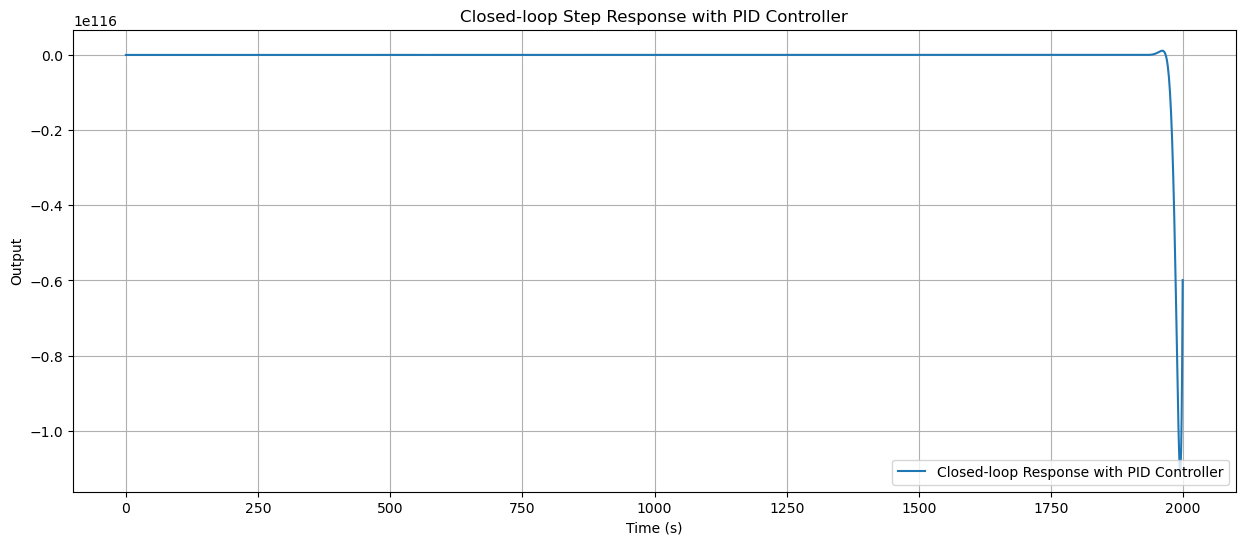

In [13]:
K_u = 750 # Gain from simulation for oscillations with pure proportional control
K_p = 0.6 * K_u # Gain for PID controller using Ziegler-Nichols tuning rules
T_i = 40
T_d = 10

# Calculate integral and derivative gains
K_i = K_p / T_i
K_d = K_p * T_d

# Design transfer function for PID controller
num = [K_d, K_p, K_i]  # PID controller numerator coefficients
den = [1, 0]  # PID controller denominator coefficients (s^2 term for derivative action)

PID_Controller = cs.TransferFunction(num, den)
Closed_Loop_PID = cs.feedback(PID_Controller * Gs_dead_time, 1)

# Step response of closed-loop system with PID controller
t_cl, y_cl = cs.step_response(Closed_Loop_PID, t)

# Plotting closed-loop response with PID controller
plt.figure(figsize=(15, 6))
plt.plot(t_cl, y_cl, label='Closed-loop Response with PID Controller')
plt.title('Closed-loop Step Response with PID Controller')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()